In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [19]:
CSV_PATH = "/Users/akashsaha/Desktop/High-Performance-Computing/Heatmap/PyTorch/Results/all_profiles.csv"   
df = pd.read_csv(CSV_PATH)

print(df.head())

   intra_threads  inter_threads  batch_size  data_load_time_sec  \
0              1              1         128            2.018107   
1              1              2         128            1.974575   
2              1              3         128            1.974511   
3              1              4         128            2.106145   
4              2              1         128            2.010289   

   model_init_time_sec  train_time_total_sec  forward_time_sec  \
0             0.004190           1795.388610        678.876510   
1             0.004135           1793.141679        672.957943   
2             0.004030           1795.007476        684.290005   
3             0.004096           1804.449178        686.700858   
4             0.006586           1753.294129        635.428070   

   backward_time_sec  optimizer_time_sec  eval_time_sec  test_accuracy  
0        1073.232432            1.674345      23.159221         0.6002  
1        1076.651007            1.671802      23.30190

In [20]:
OUT_DIR = "heatmaps"
os.makedirs(OUT_DIR, exist_ok=True)

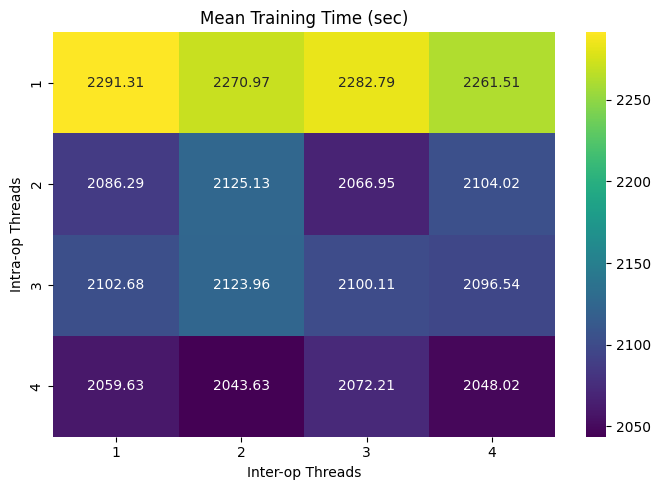

In [21]:
train_map = df.pivot_table(
    index="intra_threads",
    columns="inter_threads",
    values="train_time_total_sec",
    aggfunc="mean"   # ← KEY FIX
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(train_map, annot=True, fmt=".2f", cmap="viridis")
plt.title("Mean Training Time (sec)")
plt.xlabel("Inter-op Threads")
plt.ylabel("Intra-op Threads")
plt.tight_layout()
plt.show()

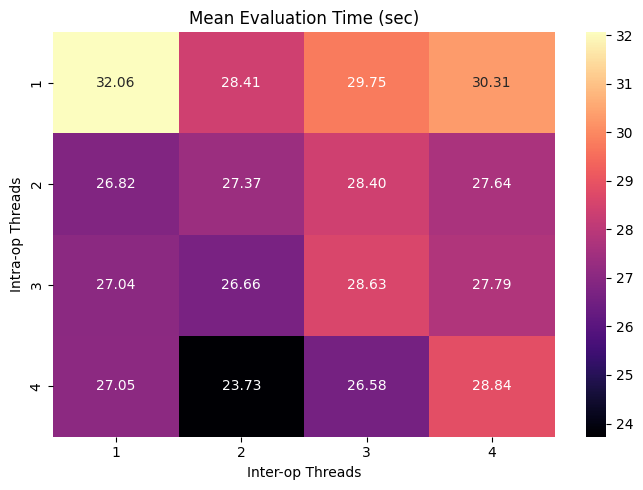

In [22]:
eval_map = df.pivot_table(
    index="intra_threads",
    columns="inter_threads",
    values="eval_time_sec",
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(eval_map, annot=True, fmt=".2f", cmap="magma")
plt.title("Mean Evaluation Time (sec)")
plt.xlabel("Inter-op Threads")
plt.ylabel("Intra-op Threads")
plt.tight_layout()
plt.show()

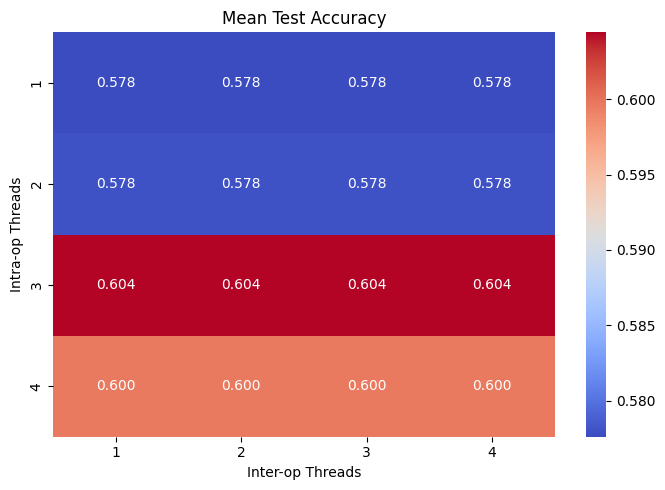

In [ ]:
acc_map = df.pivot_table(
    index="intra_threads",
    columns="inter_threads",
    values="test_accuracy",
    aggfunc="mean"  
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(acc_map, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Mean Test Accuracy")
plt.xlabel("Inter-op Threads")
plt.ylabel("Intra-op Threads")
plt.tight_layout()
plt.show()

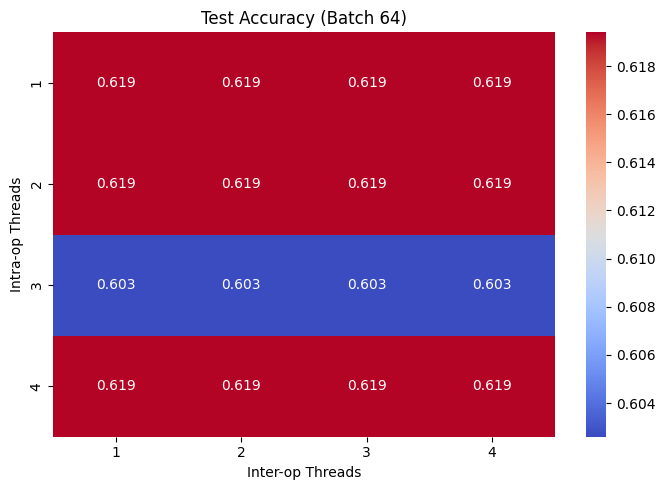

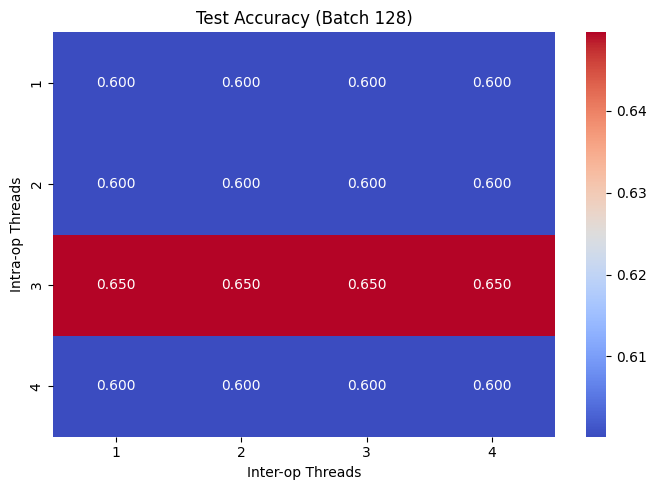

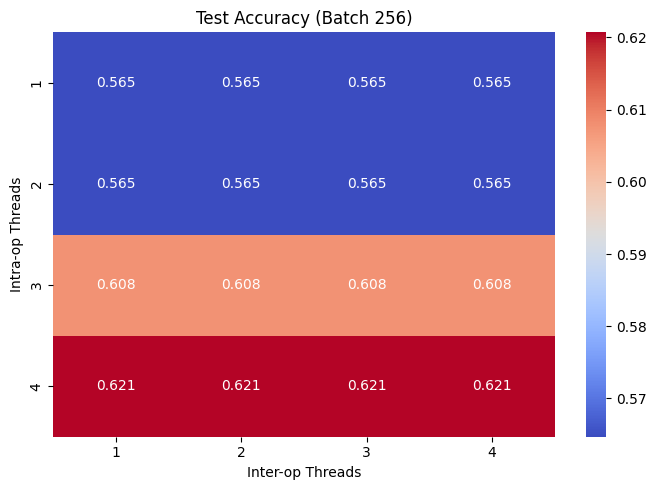

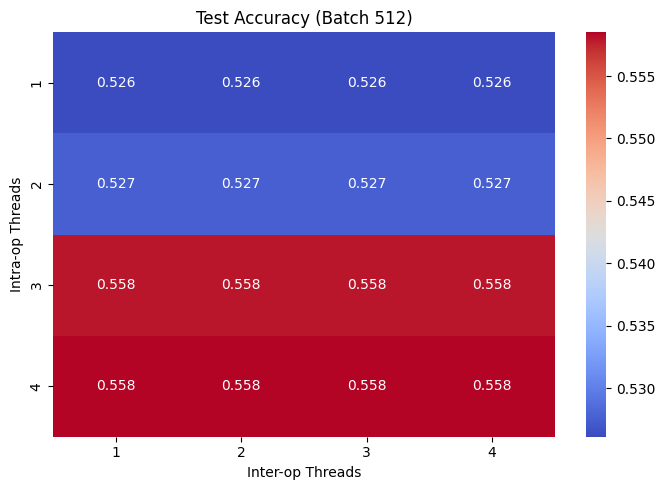

In [24]:
for batch in sorted(df["batch_size"].unique()):
    sub = df[df["batch_size"] == batch]

    acc_map = sub.pivot_table(
        index="intra_threads",
        columns="inter_threads",
        values="test_accuracy",
        aggfunc="mean"
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(acc_map, annot=True, fmt=".3f", cmap="coolwarm")
    plt.title(f"Test Accuracy (Batch {batch})")
    plt.xlabel("Inter-op Threads")
    plt.ylabel("Intra-op Threads")
    plt.tight_layout()
    plt.show()

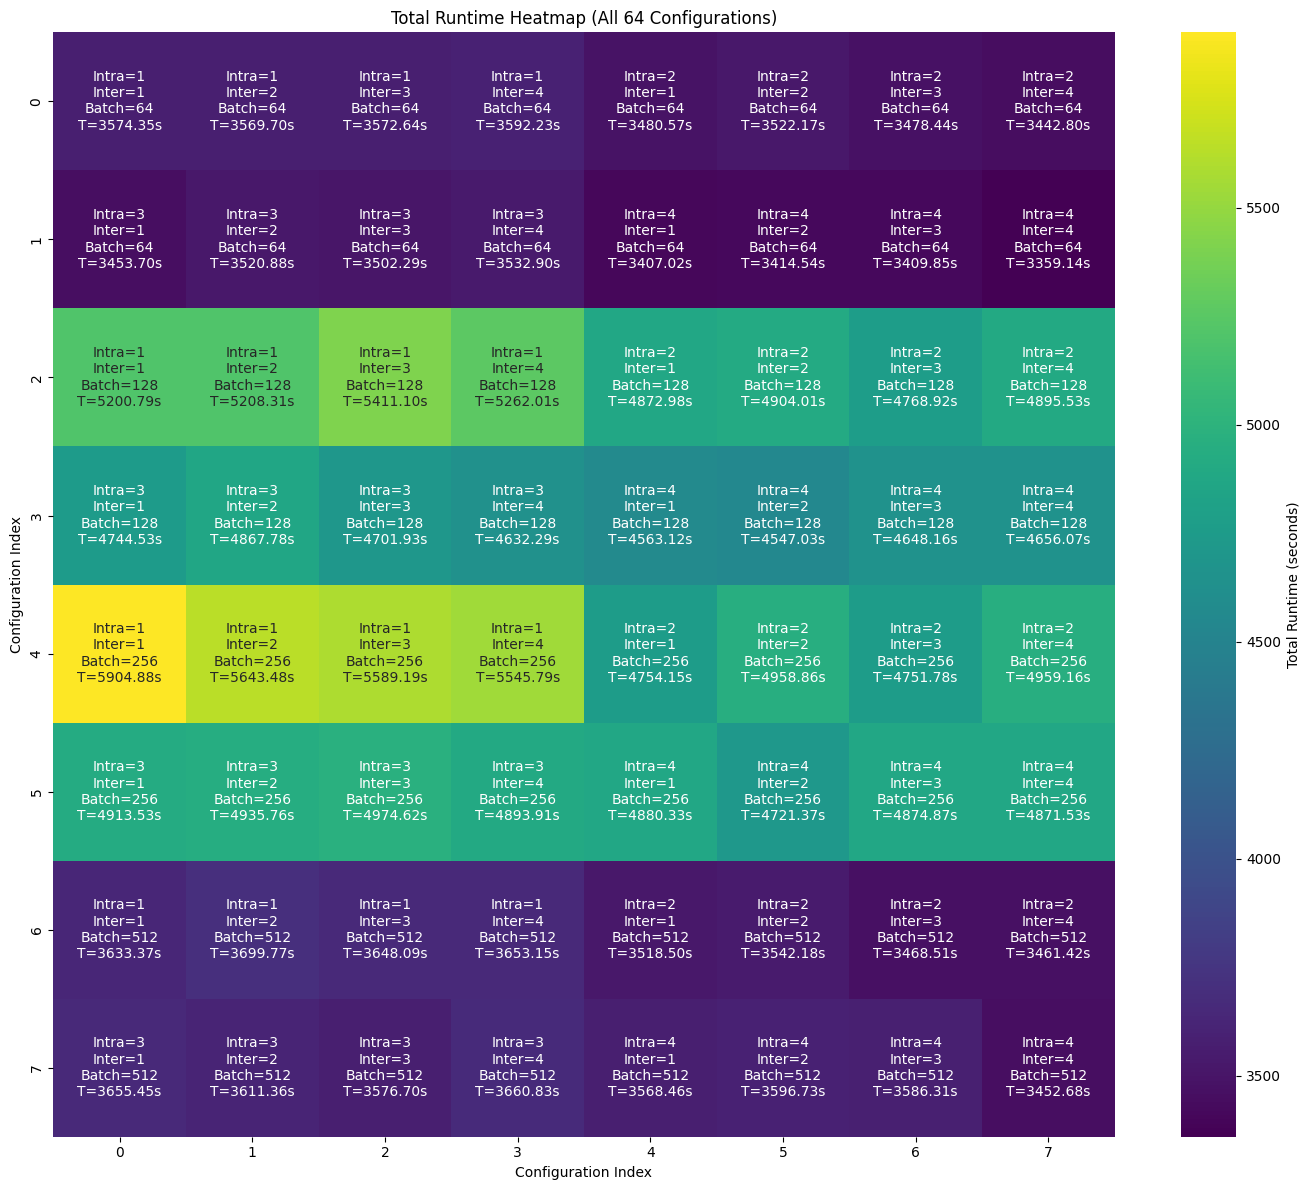

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CSV_PATH = "/Users/akashsaha/Desktop/High-Performance-Computing/Heatmap/PyTorch/Results/all_profiles_pytorch.csv"
df = pd.read_csv(CSV_PATH)


TOTAL_COL = "total_time"
assert TOTAL_COL in df.columns, "total_time column not found"


agg = (
    df.groupby(
        ["intra_threads", "inter_threads", "batch_size"],
        as_index=False
    )[TOTAL_COL]
    .mean()
)


agg = agg.sort_values(
    by=["batch_size", "intra_threads", "inter_threads"]
).reset_index(drop=True)


assert len(agg) == 64, f"Expected 64 configs, got {len(agg)}"


heatmap_data = agg[TOTAL_COL].values.reshape(8, 8)


labels = agg.apply(
    lambda r: (
        f"Intra={int(r.intra_threads)}\n"
        f"Inter={int(r.inter_threads)}\n"
        f"Batch={int(r.batch_size)}\n"
        f"T={r[TOTAL_COL]:.2f}s"
    ),
    axis=1
).values.reshape(8, 8)


plt.figure(figsize=(14, 12))
sns.heatmap(
    heatmap_data,
    annot=labels,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "Total Runtime (seconds)"}
)

plt.title("Total Runtime Heatmap (All 64 Configurations)")
plt.xlabel("Configuration Index")
plt.ylabel("Configuration Index")
plt.tight_layout()
plt.show()

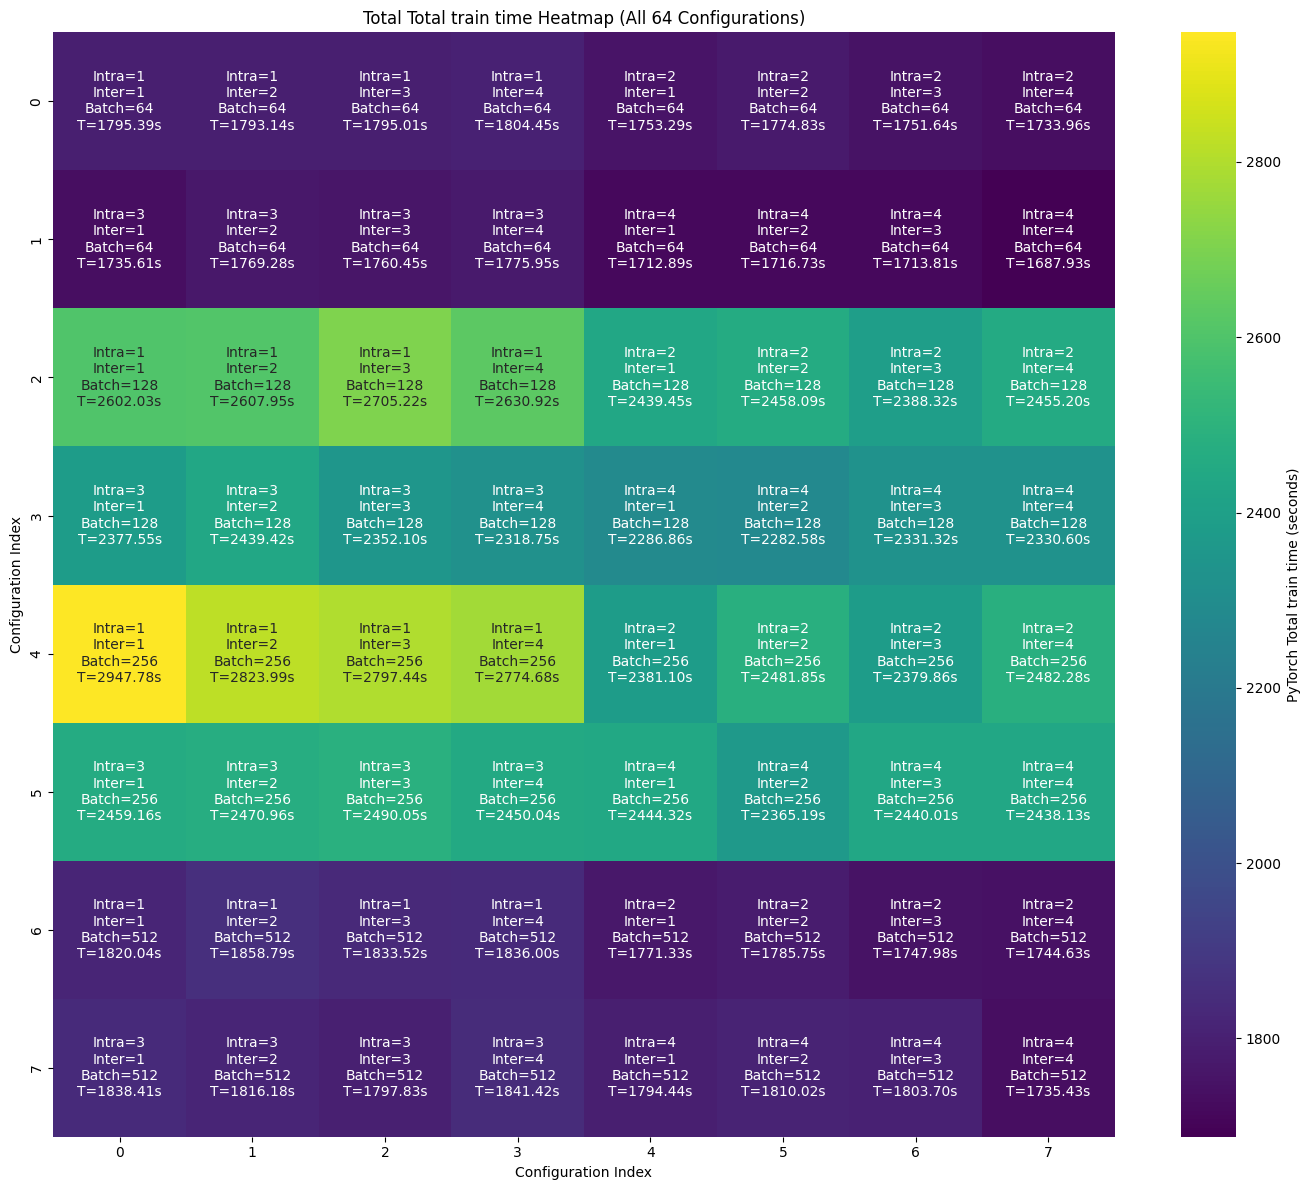

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


CSV_PATH = "/Users/akashsaha/Desktop/High-Performance-Computing/Heatmap/PyTorch/Results/all_profiles_pytorch.csv"
df = pd.read_csv(CSV_PATH)


TOTAL_COL = "train_time_total_sec"
assert TOTAL_COL in df.columns, "total_time column not found"


agg = (
    df.groupby(
        ["intra_threads", "inter_threads", "batch_size"],
        as_index=False
    )[TOTAL_COL]
    .mean()
)


agg = agg.sort_values(
    by=["batch_size", "intra_threads", "inter_threads"]
).reset_index(drop=True)


assert len(agg) == 64, f"Expected 64 configs, got {len(agg)}"


heatmap_data = agg[TOTAL_COL].values.reshape(8, 8)


labels = agg.apply(
    lambda r: (
        f"Intra={int(r.intra_threads)}\n"
        f"Inter={int(r.inter_threads)}\n"
        f"Batch={int(r.batch_size)}\n"
        f"T={r[TOTAL_COL]:.2f}s"
    ),
    axis=1
).values.reshape(8, 8)


plt.figure(figsize=(14, 12))
sns.heatmap(
    heatmap_data,
    annot=labels,
    fmt="",
    cmap="viridis",
    cbar_kws={"label": "PyTorch Total train time (seconds)"}
)

plt.title("Total Total train time Heatmap (All 64 Configurations)")
plt.xlabel("Configuration Index")
plt.ylabel("Configuration Index")
plt.tight_layout()
plt.show()